In [1]:
from utils import demo, print_tree, show_run

from url4 import run

In [2]:
await run("https://syfthub.openmined.org!Summarize This")

'Summarize This\n\n<!doctype html>\n<html lang="en" style="color-scheme: light dark">\n  <head>\n    <!-- THEME: Prevent flash of wrong theme by applying dark class before paint -->\n    <script>\n      (function () {\n        var theme = localStorage.getItem(\'syfthub-theme\');\n        var prefersDark = window.matchMedia(\'(prefers-color-scheme: dark)\').matches;\n        if (theme === \'dark\' || (theme === \'system\' && prefersDark) || (!theme && prefersDark)) {\n          document.documentElement.classList.add(\'dark\');\n        }\n      })();\n    </script>\n\n    <!-- ESSENTIAL -->\n    <meta charset="utf-8" />\n    <meta http-equiv="x-ua-compatible" content="ie=edge" />\n    <meta name="viewport" content="width=device-width, initial-scale=1" />\n\n    <!-- PERFORMANCE: Preconnect to external domains (Web Interface Guidelines) -->\n    <link rel="preconnect" href="https://fonts.googleapis.com" />\n    <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin />\n\n   

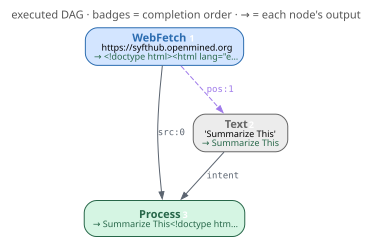

#,node,inputs,output
1,WebFetch https://syfthub.openmined.org,—,"<!doctype html> <html lang=""en"" style=""…"
2,Text 'Summarize This',pos:1=<!doctype html> <…,Summarize This
3,Process,"src:0=<!doctype html> <…, intent=Summarize This",Summarize This <!doctype html> <html l…


In [3]:
await show_run("https://syfthub.openmined.org!Summarize This")

In [6]:
# name=… binds a source; $article / $style inject it. Dashed edges = the $context flow.
expr = (
    "(article=https://news.example.com/ai-act, style='plain English')"
    "!'Summarize $article in $style'"
)
await run(expr, demo)

"Summarize EU lawmakers gave final approval to the AI Act, the first broad law governing artificial intelligence. It ranks systems by risk, bans social scoring and manipulative uses, and requires transparency and human oversight for high-risk uses in hiring, credit, and healthcare. Most rules phase in over two years. in 'plain English'"

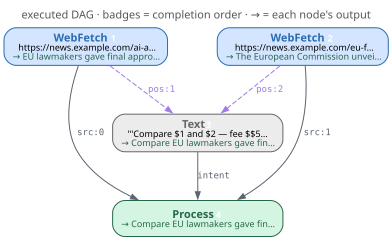

#,node,inputs,output
1,WebFetch https://news.example.com/ai-a…,—,EU lawmakers gave final approval to the…
2,WebFetch https://news.example.com/eu-f…,—,The European Commission unveiled a EUR …
3,"Text ""'Compare $1 and $2 — fee $$5…","pos:1=EU lawmakers gave…, pos:2=The European Comm…",Compare EU lawmakers gave final approva…
4,Process,"src:0=EU lawmakers gave…, src:1=The European Comm…, intent=Compare EU lawmak…",Compare EU lawmakers gave final approva…


In [7]:
# $1..$N reference sources by position; $$ is a literal $.
expr = (
    "(https://news.example.com/ai-act, https://news.example.com/eu-funding)"
    "!'Compare $1 and $2 — fee $$5'"
)
await show_run(expr, demo)

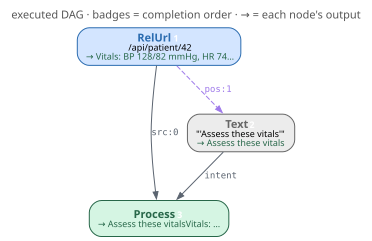

#,node,inputs,output
1,RelUrl /api/patient/42,—,"Vitals: BP 128/82 mmHg, HR 74 bpm, Temp…"
2,"Text ""'Assess these vitals'""",pos:1=Vitals: BP 128/82…,Assess these vitals
3,Process,"src:0=Vitals: BP 128/82…, intent=Assess these vita…",Assess these vitals Vitals: BP 128/82 …


In [8]:
# A /path source is fetched relative to the node (here, an internal patient API).
await show_run("/api/patient/42!'Assess these vitals'", demo)

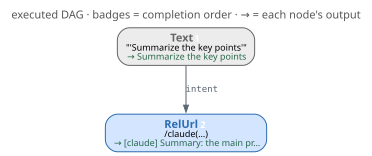

#,node,inputs,output
1,"Text ""'Summarize the key points'""",—,Summarize the key points
2,RelUrl /claude(…),intent=Summarize the key…,"[claude] Summary: the main provisions, …"


In [10]:
# /path(context)!intent is a relative EXPRESSION: fetched from the localhost
# /claude route as /claude?q=(context)!intent (a RelUrl node — no separate "call").
await show_run("/claude(https://news.example.com/ai-act)!'Summarize the key points'", demo)

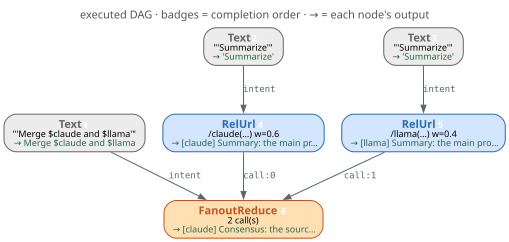

#,node,inputs,output
1,"Text ""'Merge $claude and $llama'""",—,Merge $claude and $llama
2,"Text ""'Summarize'""",—,'Summarize'
3,"Text ""'Summarize'""",—,'Summarize'
4,RelUrl /claude(…) w=0.6,intent='Summarize',"[claude] Summary: the main provisions, …"
5,RelUrl /llama(…) w=0.4,intent='Summarize',"[llama] Summary: the main provisions, o…"
6,FanoutReduce 2 call(s),"intent=Merge $claude and…, call:0=[claude] Summary:…, call:1=[llama] Summary: …",[claude] Consensus: the sources broadly…


In [11]:
# Weighted ensemble: two model calls run in parallel; one FanoutReduce node merges them.
expr = (
    "(claude:0.6:/claude(https://news.example.com/ai-act)!'Summarize',"
    "llama:0.4:/llama(https://news.example.com/ai-act)!'Summarize')"
    "!'Merge $claude and $llama'"
)
await show_run(expr, demo)

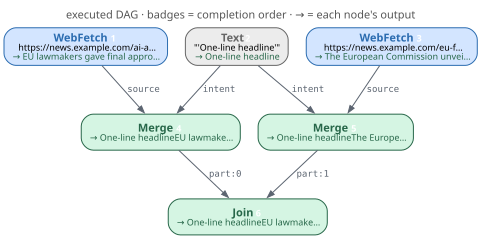

#,node,inputs,output
1,WebFetch https://news.example.com/ai-a…,—,EU lawmakers gave final approval to the…
2,"Text ""'One-line headline'""",—,One-line headline
3,WebFetch https://news.example.com/eu-f…,—,The European Commission unveiled a EUR …
4,Merge,"source=EU lawmakers gave…, intent=One-line headline",One-line headline EU lawmakers gave fi…
5,Merge,"source=The European Comm…, intent=One-line headline",One-line headline The European Commiss…
6,Join,"part:0=One-line headline…, part:1=One-line headline…",One-line headline EU lawmakers gave fi…


In [12]:
# !* applies the same intent to each source independently (note the single shared Text node).
expr = "(https://news.example.com/ai-act, https://news.example.com/eu-funding)!*'One-line headline'"
await show_run(expr, demo)

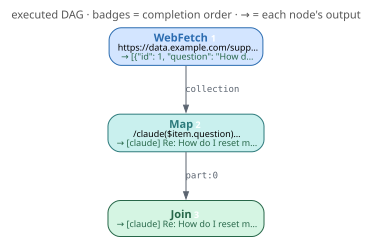

#,node,inputs,output
1,WebFetch https://data.example.com/supp…,—,"[{""id"": 1, ""question"": ""How do I reset …"
2,Map /claude($item.question)…,"collection=[{""id"": 1, ""quest…",[claude] Re: How do I reset my password…
3,Join,part:0=[claude] Re: How …,[claude] Re: How do I reset my password…


In [13]:
# collection*(body) runs the body once per row; $item.field binds the row (Map expands at runtime).
expr = "https://data.example.com/support-tickets*(/claude($item.question)!'Answer')"
await show_run(expr, demo)

In [14]:
await run(expr, demo)

'[claude] Re: How do I reset my password? — follow the documented steps; escalate if needed.\n[claude] Re: Why was my card declined at checkout? — follow the documented steps; escalate if needed.\n[claude] Re: Can I export my data as CSV? — follow the documented steps; escalate if needed.'

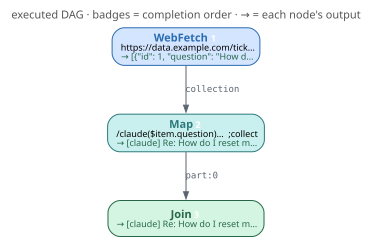

#,node,inputs,output
1,WebFetch https://data.example.com/tick…,—,"[{""id"": 1, ""question"": ""How do I reset …"
2,Map /claude($item.question)… ;collect,"collection=[{""id"": 1, ""quest…",[claude] Re: How do I reset my password…
3,Join,part:0=[claude] Re: How …,[claude] Re: How do I reset my password…


In [15]:
# on_error=collect turns a failing row (missing $item.question) into an {"error": …} output.
expr = (
    "https://data.example.com/tickets-messy*(/claude($item.question)!'Answer')"
    ";foreach.on_error=collect"
)
await show_run(expr, demo)

In [ ]:
# The `*` operator iterates a collection: `collection*(body)!intent` runs the
# body once per item (spec §5.3). Here each paper title is summarized via /claude.
await show_run(
    "https://data.example.com/reading-list*(/claude($item)!'Summarize this paper in one line')",
    demo,
)

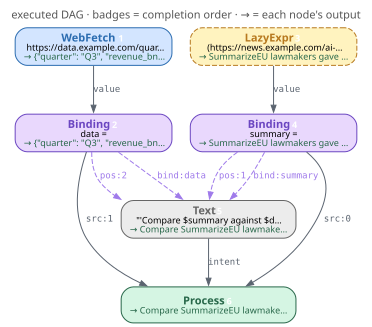

#,node,inputs,output
1,WebFetch https://data.example.com/quar…,—,"{""quarter"": ""Q3"", ""revenue_bn"": 4.2, ""y…"
2,Binding data =,"value={""quarter"": ""Q3"",…","{""quarter"": ""Q3"", ""revenue_bn"": 4.2, ""y…"
3,LazyExpr (https://news.example.com/ai-…,—,Summarize EU lawmakers gave final appr…
4,Binding summary =,value=Summarize EU law…,Summarize EU lawmakers gave final appr…
5,"Text ""'Compare $summary against $d…","pos:1=Summarize EU law…, pos:2={""quarter"": ""Q3"",…, bind:summary=Summarize EU law…, bind:data={""quarter"": ""Q3"",…",Compare Summarize EU lawmakers gave fi…
6,Process,"src:0=Summarize EU law…, src:1={""quarter"": ""Q3"",…, intent=Compare Summarize…",Compare Summarize EU lawmakers gave fi…


In [17]:
# A nested (…)!… is a LazyExpr node — compiled only when execution reaches it.
expr = (
    "(summary=(https://news.example.com/ai-act)!'Summarize',"
    " data=https://data.example.com/quarterly.json)"
    "!'Compare $summary against $data'"
)
await show_run(expr, demo)

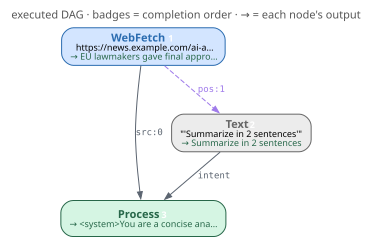

#,node,inputs,output
1,WebFetch https://news.example.com/ai-a…,—,EU lawmakers gave final approval to the…
2,"Text ""'Summarize in 2 sentences'""",pos:1=EU lawmakers gave…,Summarize in 2 sentences
3,Process,"src:0=EU lawmakers gave…, intent=Summarize in 2 se…",<system>You are a concise analyst.</sys…


In [18]:
# process(sources, intent, scope) is the overridable merge step — here, a chat-style template.
async def as_chat(sources, intent, scope):
    return f"<system>You are a concise analyst.</system>\n<user>{intent}\n\n{sources}</user>"


expr = "(https://news.example.com/ai-act)!'Summarize in 2 sentences'"
await show_run(expr, demo, process=as_chat)

In [23]:
# show_graph renders STRUCTURE without executing — nested groups stay LazyExpr.
expr = (
    "(article=https://news.example.com/ai-act,"
    " claude:0.6:/claude($article)!'Summarize',"
    " (draft, notes)!'Combine')"
    "!'Brief: $article'"
)
await show_run(expr)

Traceback (most recent call last):
  File "/home/junior/.cache/uv/archive-v0/Vdlgo5WFzoLqJJcU/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3746, in run_code
    await eval(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1359546/907135542.py", line 8, in <module>
    await show_run(expr)
  File "/home/junior/workspace/screamingface/packages/url4/examples/utils.py", line 313, in show_run
    result, sink, records = await trace_run(target, io, **run_kwargs)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/junior/workspace/screamingface/packages/url4/examples/utils.py", line 253, in trace_run
    result = await run(wrap(sink), io, **run_kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/junior/workspace/screamingface/packages/url4/src/url4/dag/executor.py", line 210, in run
    return await Executor(run_ctx).execute(_to_node(target, registry))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [22]:
# print_tree: zero-dependency ASCII view (works even without the Graphviz binary).
expr = (
    "(https://data.example.com/support-tickets*(/claude($item.question)!'Answer'))"
    "!'Summarize resolutions'"
)
print_tree(expr)

└─ Reduce 'Summarize resolutions'
   └─ rows: Map /claude($item.question)…
      └─ collection: WebFetch https://data.example.com/supp…


In [ ]:
# Each failure mode is a typed exception (run() surfaces them; show_run would re-raise).
messy = "https://data.example.com/tickets-messy*(/claude($item.question)!'Answer')"
cases = [
    "(unclosed",  # ParseError  — malformed grammar
    messy,  # ScopeError  — row missing $item.question
    "https://nowhere.example.com/x!'go'",  # ResolutionError — unknown URL
    "https://data.example.com/webpage*($item)!x",  # CollectionError — HTML, not data
]
for expr in cases:
    try:
        await run(expr, demo)
    except Exception as e:
        print(f"{type(e).__name__:16}: {str(e).splitlines()[0]}")